In [1]:
import numpy as np
from sympy import symbols, expand, binomial
import re

En esta nueva versión los coeficientes de $g_k$ se calculan de forma directa y no numérica.

In [2]:
ROUND_VALUE = 10

In [3]:
# Función auxiliar para poder tratar el output de la 
# función expand
def transform_key(key):
    key = str(key)

    if key == '1':
        return 0
    
    if key == 'w':
        return 1
    
    match = re.search(r'w\*\*([0-9]+)', key)
    return int(match.group(1))
    
    

In [4]:
w = symbols('w')
def calculate_coefficients_of_gk(k):
    '''
    Devuelve coeficientes de la serie de cosenos de g_k
    '''
    g_k = 0

    for l in range(k + 1):
        g_k += binomial(2 * k + 1, k - l) * (1 - w)**(k - l) * (1 + w)**l

    g_k *= (1 + w)**(k + 1) / (2**(2 * k + 1))

    expanded_gk = expand(g_k).as_coefficients_dict()

  

    coeff_dict = {transform_key(k): v for k, v in 
                  expanded_gk.items()}

    return coeff_dict

In [5]:
def get_conversion_dict(max_exponent):
    '''
        Devuelve un diccionario exponente, lista de exponentes
        con la equivalencia cos(w)^n = sum from -n to n e^ikw
    '''

    # cos(w)^0 = 1 = e^0, cos(w) = 1/2 (e^ikw + e^-ikw)
    conversion_dict = {0: [1], 1: [1/2, 0, 1/2]}

    coef_cos = [1/2, 0, 1/2]

    for k in range(2, max_exponent+1):
        coef_cos = np.convolve(coef_cos, [1/2, 0, 1/2])
        conversion_dict[k] = coef_cos
    
    return conversion_dict

   

def transform_cos_to_exp(coeff_dict, conversion_dict=None):
    '''
    Transforma los coeficientes de la serie de cosenos de a una serie de
    exponenciales
    '''

    # Si llamamos esta función varias veces podemos precomputar 
    # el diccionario de conversión
    if not conversion_dict:
        max_exponent = max(coeff_dict.keys())
        conversion_dict = get_conversion_dict(max_exponent)

    exponential_coefs = [0]*(2*max_exponent+1)

    for l, c in coeff_dict.items():
        j = max_exponent - l
        coefs = [0]*j + [c*v for v in conversion_dict[l]] + [0]*j
        exponential_coefs = [sum(x) for x in zip(exponential_coefs, coefs)]
        


    return exponential_coefs

In [6]:
def get_coefficients_gk(k):
    
    '''
    Calcula los coeficientes de la función g_k 
    cuando se escribe como serie de exp(ikw)
    '''

    cos_coefficients = calculate_coefficients_of_gk(k)
    exp_coefficients = transform_cos_to_exp(cos_coefficients)
    return exp_coefficients


A partir de aquí, no hay ningún cambio con respecto a la versión 1.

Con los coefs de $g_k$ construimos el polinomio P(z) que es de orden $2*(2k+1)$

In [7]:
def get_roots_inside_unit_circle(coefs):
    '''
    Calcula las raíces dentro del circulo unitario
    '''

    roots = sorted(np.roots(coefs), key=abs)
    return roots[:len(roots)//2]

Hallamos las raíces de P(z) y nos quedamos con las que están dentro del círculo unidad. Con estas raíces construimos el filtro m. <br>
Los coeficientes de $m(\xi)$ los calculamos a partir de sus raíces. <br>

In [8]:
def get_filter_coefficients(roots):
    '''
    Calcula los coeficientes del filtro a partir de las raices
    h_0 = (-1)^n * r1*r2*...*rn
    ....
    h_(n-1) = -(r1 + r2 + ... + rn)
    h_n = 1

    '''

    coefs = [1]
    for r in roots:
        coefs = np.convolve(coefs, [1, -r])

    f = np.sqrt(2)/sum(coefs)

    #Normalizar 
    return [f*c for c in coefs]

In [9]:
def get_Daubechies_filter(k):
    coefs = get_coefficients_gk(k)
    roots = get_roots_inside_unit_circle(coefs)
    filter_coefs = get_filter_coefficients(roots)

    # Los coeficientes han de ser reales. Forzamos la parte imaginaria a 0
    # para contrarestar errores de redondeo

    filter_coefs = np.round(np.real(filter_coefs), ROUND_VALUE)
    return filter_coefs

In [10]:
# imprimimos valores de los filtros. 
# (k+1 para seguir con la notación de la tabla que aparece en Daubechies Ten Lectures On Wavelets)
for k in range(1, 10):
    print(k+1, get_Daubechies_filter(k))

2 [ 0.48301947  0.83650114  0.22408732 -0.12939437]
3 [ 0.33348045  0.80723415  0.45868921 -0.13526811 -0.08506288  0.03514074]
4 [ 0.2335222   0.71827929  0.62626322 -0.0323071  -0.18483341  0.03158897
  0.03215478 -0.01045438]
5 [ 0.16696358  0.61569379  0.71710061  0.12082959 -0.24025949 -0.02536097
  0.07509751 -0.00725431 -0.01179544  0.00319866]
6 [ 0.1221703   0.51959846  0.74844992  0.27657862 -0.23586068 -0.11009183
  0.09777616  0.02053205 -0.02960697  0.00147242  0.00417805 -0.00098295]
7 [ 9.17449206e-02  4.37135169e-01  7.40782585e-01  4.09572112e-01
 -1.82729315e-01 -1.92381649e-01  8.68659720e-02  6.37829150e-02
 -3.93841063e-02 -1.10853644e-02  1.12582350e-02 -2.16714500e-04
 -1.43150610e-03  3.00308900e-04]
8 [ 7.33366548e-02  3.78172788e-01  7.16307894e-01  4.99483889e-01
 -1.13193680e-01 -2.47966998e-01  5.32340249e-02  1.02922462e-01
 -3.46418009e-02 -3.00312950e-02  1.56324758e-02  4.56231730e-03
 -4.01556720e-03  5.04898000e-05  4.46780100e-04 -8.68708000e-05]
9 [

In [11]:
print(get_coefficients_gk(2))

[0.00585937500000000, 0, -0.0488281250000000, 0, 0.292968750000000, 1/2, 0.292968750000000, 0, -0.0488281250000000, 0, 0.00585937500000000]


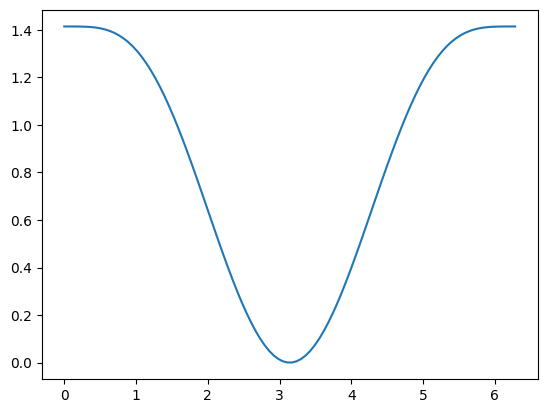

In [16]:
import cmath

def norm_of_complex(x):
    # Define the complex number
    # 0.48301947  0.83650114  0.22408732 -0.12939437
    z2 = 0.48301947 + 0.83650114 * cmath.exp(1j*x) + 0.22408732 * cmath.exp(1j*2*x) - 0.12939437 * cmath.exp(1j*3*x)
    z = 1/2 + 1/2 * cmath.exp(1j*x)  # 1j represents the imaginary unit (sqrt(-1))
    
    # Calculate the norm (magnitude) of the complex number
    norm = abs(z2)
    
    return norm

values = np.linspace(0, 2*np.pi, 100)
norms = [norm_of_complex(x) for x in values]

import matplotlib.pyplot as plt
plt.plot(values, norms)
